# Ablation Results Analysis
This notebook analyzes the ablation statistics.

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Load the dataset
df = pd.read_csv('ablation-results_statistics.csv')
df.head()

,metric,Model,Prompt_level,Processor,count,mean,median,std,min,Q1,Q3,max,IQR,lower_whisker,upper_whisker,outlier_count
0,Precision,gpt5,abla-l1,psg,30,0.826513,0.827300,0.010443,0.807427,0.818332,0.834930,0.847317,0.016598,0.807427,0.847317,0
1,Precision,gpt5,abla-l1,sg,3,0.831381,0.836078,0.013932,0.815708,0.825893,0.839218,0.842357,0.013324,0.815708,0.842357,0
2,Precision,gpt5,abla-l1,tpusg,30,0.810734,0.816312,0.014359,0.783676,0.797119,0.819960,0.834903,0.022841,0.783676,0.834903,0
3,Precision,gpt5,abla-l2,psg,30,0.798674,0.799578,0.013972,0.776612,0.788429,0.806920,0.821753,0.018491,0.776612,0.821753,0
4,Precision,gpt5,abla-l2,sg,21,0.819970,0.816256,0.009968,0.807338,0.813042,0.824660,0.839926,0.011618,0.807338,0.839926,0


## 1. Compound Box Plot
Multiple subplots for each metric (row) and processor (column). Models are on the x-axis, grouped by prompt level.

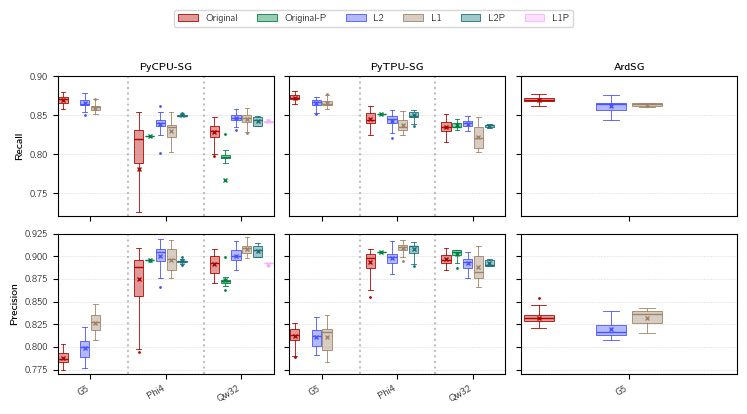

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
# Metrics and Processors to plot
metrics = ['Recall', 'Precision']
processors = ['psg', 'tpusg', 'sg']


# ── Font & style constants ────────────────────────────────────────────────────
FONT_FAMILY  = 'CMU Bright'
TITLE_SIZE   = 8
TITLE_WEIGHT = 'bold'
LABEL_SIZE   = 8
LABEL_WEIGHT = 'bold'
TICK_SIZE    = 7
LEGEND_SIZE  = 7

BOX_LINEWIDTH    = 0.6   # was implicit 1.5 in bxp styling
MEAN_MARKER_SIZE = 3     # was 6
FLIER_MARKER_SIZE = 2    # was 4
MEDIAN_LINEWIDTH  = 1.0  # was 1.5
GRID_ALPHA        = 0.5
SEPARATOR_ALPHA   = 0.4
BOX_WIDTH = 0.85   # in data units; default is 0.5 — increase to fatten


plt.rcParams.update({
    'font.family':           FONT_FAMILY,
    'font.size':             TICK_SIZE,
    'axes.labelsize':        LABEL_SIZE,
    'axes.titlesize':        TITLE_SIZE,
    'xtick.labelsize':       TICK_SIZE,
    'ytick.labelsize':       TICK_SIZE,
    'legend.fontsize':       LEGEND_SIZE,
    'legend.title_fontsize': LABEL_SIZE,
})

# ── Figure ────────────────────────────────────────────────────────────────────
ONE_MM = 1 / 25.4
fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=len(processors),
    figsize=(190 * ONE_MM, 100 * ONE_MM),  # 7.48 × 3.94 in
    sharey='row',
    sharex='col',
)

# Y-limits per metric (fill in with your desired ranges)
YLIMS = {
    'Recall':    (0.72, 0.9),
    'Precision': (0.77, 0.925),
}

# X-axis labels and groups
models = sorted(df['Model'].unique())
raw_prompts = sorted(df['Prompt_level'].unique())
target_order = ['original', 'original-p','abla-l2', 'abla-l1',  'abla-2p','abla-1p']
prompts = [p for p in target_order if p in raw_prompts]


prompt_colors = {
    'original':  '#B10600',
    'abla-l2':  '#4854FF',
    'abla-l1':  '#9E8367',
    'original-p':  "#008142",
    'abla-2p':  "#1A737A",
    'abla-1p':  "#F5B2FF"
}

model_name_map = {'gpt5': 'G5', 'phi4': 'Phi4', 'qw32': 'Qw32'}
processor_title_map = {'psg': 'PyCPU-SG', 'tpusg': 'PyTPU-SG', 'sg': 'ArdSG'}

for i, metric in enumerate(metrics):
    for j, processor in enumerate(processors):
        ax = axes[i, j]
        sub_df = df[(df['metric'] == metric) & (df['Processor'] == processor)]

        # ── NEW: only lay out models that actually have rows ──────────────
        active_models = [m for m in models if not sub_df[sub_df['Model'] == m].empty]
        # ─────────────────────────────────────────────────────────────────

        stats = []
        positions = []
        labels = []

        model_ticks = []
        model_labels = []
        total_positions = len(active_models) * (len(prompts) + 1)  # ← use active_models

        for idx_model, model in enumerate(active_models):          # ← use active_models
            model_df = sub_df[sub_df['Model'] == model]
            start_pos = idx_model * (len(prompts) + 1) + 1
            end_pos = start_pos + len(prompts) - 1

            if not model_df.empty:
                for idx_prompt, prompt in enumerate(prompts):
                    row = model_df[model_df['Prompt_level'] == prompt]
                    if not row.empty:
                        row = row.iloc[0]
                        fliers = []
                        if row['min'] < row['lower_whisker']:
                            fliers.append(row['min'])
                        if row['max'] > row['upper_whisker']:
                            fliers.append(row['max'])
                        stat = {
                            'med': row['median'],
                            'q1': row['Q1'],
                            'q3': row['Q3'],
                            'whislo': row['lower_whisker'],
                            'whishi': row['upper_whisker'],
                            'mean': row['mean'],
                            'fliers': fliers
                        }
                        stats.append(stat)
                        positions.append(start_pos + idx_prompt)
                        labels.append(prompt)

            model_ticks.append((start_pos + end_pos) / 2)
            model_labels.append(model_name_map.get(model, model))

            if idx_model < len(active_models) - 1:  # ← use active_models
                if processor != 'sg':
                    ax.axvline(x=end_pos + 1, color='gray', linestyle=':', alpha=0.5)

        # … rest of the bxp / formatting code stays exactly the same …
            
        if stats:
            bplot = ax.bxp(
                stats,
                positions=positions,
                widths=BOX_WIDTH,
                patch_artist=True,
                showfliers=True,
                showmeans=True,
                whiskerprops=dict(linestyle='-', linewidth=BOX_LINEWIDTH),
                medianprops=dict(linewidth=MEDIAN_LINEWIDTH, linestyle='-'),
                meanprops=dict(marker='x', markersize=MEAN_MARKER_SIZE),
                flierprops=dict(marker='.', markersize=FLIER_MARKER_SIZE),
                boxprops=dict(linewidth=BOX_LINEWIDTH),
                capprops=dict(linewidth=BOX_LINEWIDTH),
            )

            for k, label in enumerate(labels):
                c_fill = prompt_colors[label]
                c_edge = prompt_colors[label]
                c_fill_rgba = mcolors.to_rgba(c_fill, alpha=0.4)

                bplot['boxes'][k].set_facecolor(c_fill_rgba)
                bplot['boxes'][k].set_edgecolor(c_edge)
                bplot['boxes'][k].set_linewidth(BOX_LINEWIDTH)   # was hardcoded 1.5

                bplot['medians'][k].set_color(c_edge)
                bplot['medians'][k].set_linewidth(MEDIAN_LINEWIDTH)
                bplot['means'][k].set_markeredgecolor(c_edge)
                bplot['means'][k].set_markersize(MEAN_MARKER_SIZE)
                bplot['fliers'][k].set_markeredgecolor(c_edge)
                bplot['fliers'][k].set_markerfacecolor(c_edge)
                bplot['fliers'][k].set_markersize(FLIER_MARKER_SIZE)

                bplot['whiskers'][2*k].set_color(c_edge)
                bplot['whiskers'][2*k].set_linewidth(BOX_LINEWIDTH)
                bplot['whiskers'][2*k+1].set_color(c_edge)
                bplot['whiskers'][2*k+1].set_linewidth(BOX_LINEWIDTH)
                bplot['caps'][2*k].set_color(c_edge)
                bplot['caps'][2*k].set_linewidth(BOX_LINEWIDTH)
                bplot['caps'][2*k+1].set_color(c_edge)
                bplot['caps'][2*k+1].set_linewidth(BOX_LINEWIDTH)
            
        ax.set_xticks(model_ticks)
        ax.set_xticklabels(model_labels, fontsize=TICK_SIZE, rotation=30, ha='right')
        ax.set_xlim(0.5, total_positions - 0.5)
 

        if i == 0:
            ax.set_title(
                processor_title_map.get(processor, processor),
                fontsize=TITLE_SIZE,
                fontweight=TITLE_WEIGHT,
                pad=4,
            )
        if metric in YLIMS:
            ymin, ymax = YLIMS[metric]
            ax.set_ylim(ymin, ymax)
        ax.grid(axis='y', linestyle='--', alpha=GRID_ALPHA, linewidth=0.4)

        if j == 0:
            ax.set_ylabel(metric, fontsize=LABEL_SIZE, fontweight=LABEL_WEIGHT)

# Global Legend
legend_labels = {'original': 'Original', 'abla-l2': 'L2', 'abla-l1': 'L1','original-p':'Original-P',  'abla-2p': 'L2P', 'abla-1p': 'L1P'}
legend_handles = [
    mpatches.Patch(
        edgecolor=prompt_colors[p],
        facecolor=mcolors.to_rgba(prompt_colors[p], alpha=0.4),
        linewidth=BOX_LINEWIDTH,
        label=legend_labels.get(p, p),
    )
    for p in prompts
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=len(prompts),
    # title='Prompt Level',
    bbox_to_anchor=(0.5, 1.04),
    fontsize=LEGEND_SIZE,
    title_fontsize=LABEL_SIZE,
    frameon=True,
)

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.savefig('figs/box_ablation.pdf', dpi=500, bbox_inches='tight')
plt.savefig('figs/box_ablation.png', dpi=500, bbox_inches='tight')
plt.show()


## 1.5 Some value print

In [103]:
# New cell: compute lowest outlier per (metric, processor) and print as a table

rows = []

for metric in metrics:
    for processor in processors:
        sub_df = df[(df['metric'] == metric) & (df['Processor'] == processor)]
        if sub_df.empty:
            continue

        # same active_models definition as in the plotting code
        active_models = [m for m in models if not sub_df[sub_df['Model'] == m].empty]

        lowest_val = None
        lowest_info = None  # (model, prompt)

        for model in active_models:
            model_df = sub_df[sub_df['Model'] == model]

            for prompt in prompts:
                row = model_df[model_df['Prompt_level'] == prompt]
                if row.empty:
                    continue

                r = row.iloc[0]

                # check for a lower-side outlier
                if r['min'] < r['lower_whisker']:
                    val = r['min']
                    if lowest_val is None or val < lowest_val:
                        lowest_val = val
                        lowest_info = (model, prompt)

        if lowest_val is not None and lowest_info is not None:
            rows.append({
                'metric': metric,
                'processor': processor,
                'model': model_name_map.get(lowest_info[0], lowest_info[0]),
                'prompt': lowest_info[1],
                'lowest_outlier': lowest_val,
            })

lowest_outliers = pd.DataFrame(rows)
print(lowest_outliers.to_string(index=False))

   metric processor model   prompt  lowest_outlier
   Recall       psg  Phi4 original        0.485971
   Recall     tpusg  Phi4  abla-l2        0.820932
Precision       psg  Phi4 original        0.793867
Precision     tpusg    G5 original        0.789063


## 2. Table: Mean value per Model and Prompt type

In [104]:
# Broken down by metric
print("Mean Values by Metric, Model and Prompt Type:")
metric_table = pd.pivot_table(
    df,
    values='mean',
    index=['metric', 'Processor', 'Model'],  # add Processor here
    columns='Prompt_level',
    aggfunc='mean'
)

# Reorder columns based on requested order
ordered_prompts = ['original', 'abla-l2', 'abla-l1',  'abla-2p', 'abla-1p']
ordered_prompts = [p for p in ordered_prompts if p in metric_table.columns]
diff_table = metric_table[ordered_prompts].copy()

# Round table to 2 decimal places
diff_table = diff_table.round(2)
display(diff_table)

Mean Values by Metric, Model and Prompt Type:


Prompt_level               original  abla-l2  abla-l1  abla-2p  abla-1p
metric    Processor Model                                              
F1        psg       gpt5       0.83     0.83     0.84      NaN      NaN
                    phi4       0.82     0.87     0.86     0.87      NaN
                    qw32       0.86     0.87     0.88     0.87     0.87
          sg        gpt5       0.85     0.84     0.85      NaN      NaN
          tpusg     gpt5       0.84     0.84     0.84      NaN      NaN
                    phi4       0.87     0.87     0.87     0.88      NaN
                    qw32       0.86     0.86     0.85     0.86      NaN
F3        psg       gpt5       0.86     0.86     0.86      NaN      NaN
                    phi4       0.79     0.84     0.84     0.85      NaN
                    qw32       0.83     0.85     0.85     0.85     0.85
          sg        gpt5       0.87     0.86     0.86      NaN      NaN
          tpusg     gpt5       0.87     0.86     0.86      NaN      NaN
                    phi4       0.85     0.85     0.84     0.85      NaN
                    qw32       0.84     0.84     0.83     0.84      NaN
Precision psg       gpt5       0.79     0.80     0.83      NaN      NaN
                    phi4       0.87     0.90     0.90     0.89      NaN
                    qw32       0.89     0.90     0.91     0.91     0.89
          sg        gpt5       0.83     0.82     0.83      NaN      NaN
          tpusg     gpt5       0.81     0.81     0.81      NaN      NaN
                    phi4       0.89     0.90     0.91     0.91      NaN
                    qw32       0.90     0.89     0.89     0.89      NaN
Recall    psg       gpt5       0.87     0.87     0.86      NaN      NaN
                    phi4       0.78     0.84     0.83     0.85      NaN
                    qw32       0.83     0.85     0.84     0.84     0.84
          sg        gpt5       0.87     0.86     0.86      NaN      NaN
          tpusg     gpt5       0.87     0.87     0.86      NaN      NaN
                    phi4       0.85     0.84     0.84     0.85      NaN
                    qw32       0.83     0.84     0.82     0.84      NaN

In [105]:
import pandas as pd

# ── New Cell: F1 & F3 Table ───────────────────────────────────────────────────

legend_labels       = {'original': 'Original', 'original-p': 'Original-P', 'abla-l2': 'L2', 'abla-2p': 'L2P', 'abla-l1': 'L1', 'abla-1p': 'L1P'}
model_name_map      = {'gpt5': 'G5', 'phi4': 'Phi4', 'qw32': 'Qw32'}
processor_title_map = {'psg': 'PyCPU-SG', 'tpusg': 'PyTPU-SG', 'sg': 'ArdSG'}

# ── Filter & map labels ───────────────────────────────────────────────────────
f1f3_df = df[df['metric'].isin(['F1', 'F3'])].copy()

f1f3_df['Processor']   = f1f3_df['Processor'].map(processor_title_map).fillna(f1f3_df['Processor'])
f1f3_df['Model']       = f1f3_df['Model'].map(model_name_map).fillna(f1f3_df['Model'])
f1f3_df['Prompt_level'] = f1f3_df['Prompt_level'].map(legend_labels).fillna(f1f3_df['Prompt_level'])

# ── Pivot: rows = (metric, Processor), cols = (Model, Prompt_level) ───────────
pivot = pd.pivot_table(
    f1f3_df,
    values='mean',
    index=['metric', 'Processor'],
    columns=['Model', 'Prompt_level'],
    aggfunc='mean'
)

# ── Enforce column & row order ────────────────────────────────────────────────
col_models   = ['G5', 'Phi4', 'Qw32']
col_prompts  = ['Original', 'L2', 'L1', 'L2P', 'L1P']
row_metrics  = ['F1', 'F3']
row_procs    = ['PyCPU-SG', 'PyTPU-SG', 'ArdSG']

# ── Enforce column & row order — excluding *P prompts for G5 ─────────────────
col_prompts_g5   = ['Original', 'L2', 'L1']                   # no P-variants
col_prompts_rest = ['Original', 'Original-P', 'L2', 'L1', 'L2P', 'L1P']
col_prompts_phi4 = ['Original', 'Original-P', 'L2', 'L1', 'L2P']            # no L1P
 
col_idx = pd.MultiIndex.from_tuples(
    [(m, p)
     for m in col_models
     for p in (col_prompts_g5   if m == 'G5'
               else col_prompts_phi4 if m == 'Phi4'
               else col_prompts_rest)],
    names=['Model', 'Prompt']
)

row_idx = pd.MultiIndex.from_product([row_metrics, row_procs], names=['Metric', 'Processor'])

# Changed .round(3) to .round(2) here
pivot = pivot.reindex(columns=col_idx).reindex(index=row_idx).round(2)

display(pivot)

# Optional: If you strictly need the print output to show trailing zeros (e.g., '0.80' instead of '0.8')
# pivot_formatted = pivot.map(lambda x: f"{x:.2f}" if pd.notnull(x) else "NaN")
# print(pivot_formatted)

print(pivot)

Model                  G5                 Phi4                               \
Prompt           Original    L2    L1 Original Original-P    L2    L1   L2P   
Metric Processor                                                              
F1     PyCPU-SG      0.83  0.83  0.84     0.82       0.86  0.87  0.86  0.87   
       PyTPU-SG      0.84  0.84  0.84     0.87       0.88  0.87  0.87  0.88   
       ArdSG         0.85  0.84  0.85      NaN        NaN   NaN   NaN   NaN   
F3     PyCPU-SG      0.86  0.86  0.86     0.79       0.83  0.84  0.84  0.85   
       PyTPU-SG      0.87  0.86  0.86     0.85       0.86  0.85  0.84  0.85   
       ArdSG         0.87  0.86  0.86      NaN        NaN   NaN   NaN   NaN   

Model                Qw32                                     
Prompt           Original Original-P    L2    L1   L2P   L1P  
Metric Processor                                              
F1     PyCPU-SG      0.86       0.81  0.87  0.88  0.87  0.87  
       PyTPU-SG      0.86       0.87  0.86  0.85  0.86   NaN  
       ArdSG          NaN        NaN   NaN   NaN   NaN   NaN  
F3     PyCPU-SG      0.83       0.78  0.85  0.85  0.85  0.85  
       PyTPU-SG      0.84       0.84  0.84  0.83  0.84   NaN  
       ArdSG          NaN        NaN   NaN   NaN   NaN   NaN

Model                  G5                 Phi4                               \
Prompt           Original    L2    L1 Original Original-P    L2    L1   L2P   
Metric Processor                                                              
F1     PyCPU-SG      0.83  0.83  0.84     0.82       0.86  0.87  0.86  0.87   
       PyTPU-SG      0.84  0.84  0.84     0.87       0.88  0.87  0.87  0.88   
       ArdSG         0.85  0.84  0.85      NaN        NaN   NaN   NaN   NaN   
F3     PyCPU-SG      0.86  0.86  0.86     0.79       0.83  0.84  0.84  0.85   
       PyTPU-SG      0.87  0.86  0.86     0.85       0.86  0.85  0.84  0.85   
       ArdSG         0.87  0.86  0.86      NaN        NaN   NaN   NaN   NaN   

Model                Qw32                                     
Prompt           Original Original-P    L2    L1   L2P   L1P  
Metric Processor                                              
F1     PyCPU-SG      0.86       0.81  0.87  0.88  0.87  0.87  
       PyTPU-SG      0.86       0.87